<a href="https://colab.research.google.com/github/Sharddha-Sharddha/IITMLAssignments/blob/main/WeatherForecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Dataset: https://drive.google.com/file/d/1nco_2EPtXCxmu6JlTvsURUgS7u7hyvy4/view?usp=sharing
# Problem Statement: https://drive.google

#Prepare your dataset for time series implementation
#Check for data stationarity
#Deal with non-stationary data
#Perform visualization
#Apply models to check the prediction
#Do Forecasting for the next 100 days for Humidity

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data/weather_data.csv')

In [6]:
df.head()


,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


In [8]:
df['date']= pd.to_datetime(df['date'])  #convert date datatype

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1462 non-null   datetime64[ns]
 1   meantemp      1462 non-null   float64       
 2   humidity      1462 non-null   float64       
 3   wind_speed    1462 non-null   float64       
 4   meanpressure  1462 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 57.2 KB


In [11]:
df.isnull().sum() # checking null values

,0
date,0
meantemp,0
humidity,0
wind_speed,0
meanpressure,0


In [13]:
df.duplicated().sum()  #checking duplicates

np.int64(0)

In [17]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,1462,2015-01-01 12:00:00,2013-01-01 00:00:00,2014-01-01 06:00:00,2015-01-01 12:00:00,2016-01-01 18:00:00,2017-01-01 00:00:00,NaN
meantemp,1462.0,25.495521,6.0,18.857143,27.714286,31.305804,38.714286,7.348103
humidity,1462.0,60.771702,13.428571,50.375,62.625,72.21875,100.0,16.769652
wind_speed,1462.0,6.802209,0.0,3.475,6.221667,9.238235,42.22,4.561602
meanpressure,1462.0,1011.104548,-3.041667,1001.580357,1008.563492,1014.944901,7679.333333,180.231668


In [20]:
clean_data = df.set_index('date')['humidity']

In [21]:
clean_data

,humidity
date,
2013-01-01,84.500000
2013-01-02,92.000000
2013-01-03,87.000000
2013-01-04,71.333333
2013-01-05,86.833333
...,...
2016-12-28,68.043478
2016-12-29,87.857143
2016-12-30,89.666667


<Axes: title={'center': 'humidity over time'}, xlabel='date'>

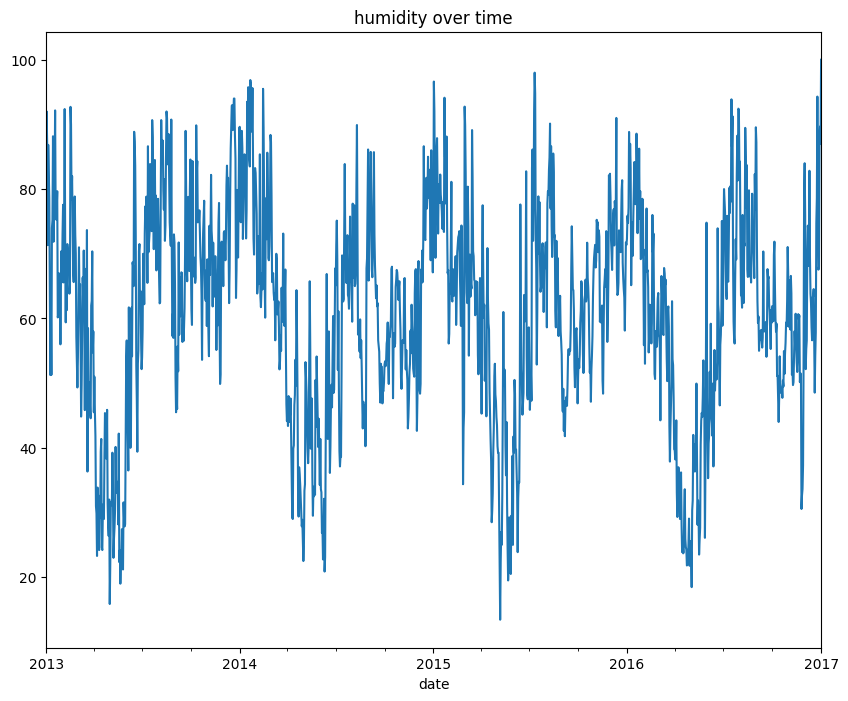

In [23]:
clean_data.plot(figsize= (10,8), title= 'humidity over time')

In [24]:
clean_data.skew()  #moderate skewness

np.float64(-0.34397725215868463)

/tmp/ipykernel_2550/2247787037.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(clean_data)


<Axes: xlabel='humidity', ylabel='Density'>

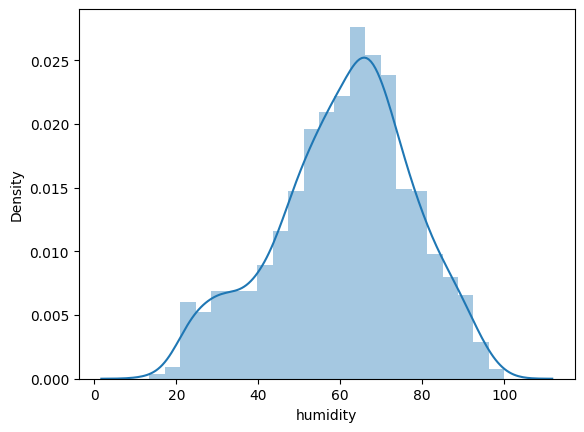

In [25]:
sns.distplot(clean_data)

**Stationary Analysis**

In [34]:
per_day_humidity = df.groupby(pd.Grouper(key = 'date', freq = 'D' ))['humidity'].sum()
per_month_humidity = df.groupby(pd.Grouper(key= 'date', freq = 'M'))['humidity'].sum()
per_year_humidity = df.groupby(pd.Grouper(key = 'date', freq = 'Y'))['humidity'].sum()

/tmp/ipykernel_2550/3181918614.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  per_month_humidity = df.groupby(pd.Grouper(key= 'date', freq = 'M'))['humidity'].sum()
/tmp/ipykernel_2550/3181918614.py:3: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  per_year_humidity = df.groupby(pd.Grouper(key = 'date', freq = 'Y'))['humidity'].sum()


In [35]:
per_day_humidity.head()

,humidity
date,
2013-01-01,84.500000
2013-01-02,92.000000
2013-01-03,87.000000
2013-01-04,71.333333
2013-01-05,86.833333


In [36]:
per_month_humidity.head()

,humidity
date,
2013-01-31,2263.892857
2013-02-28,2014.279762
2013-03-31,1779.934524
2013-04-30,1038.363095
2013-05-31,897.085714


<Axes: title={'center': 'per_month_humidity'}, xlabel='date'>

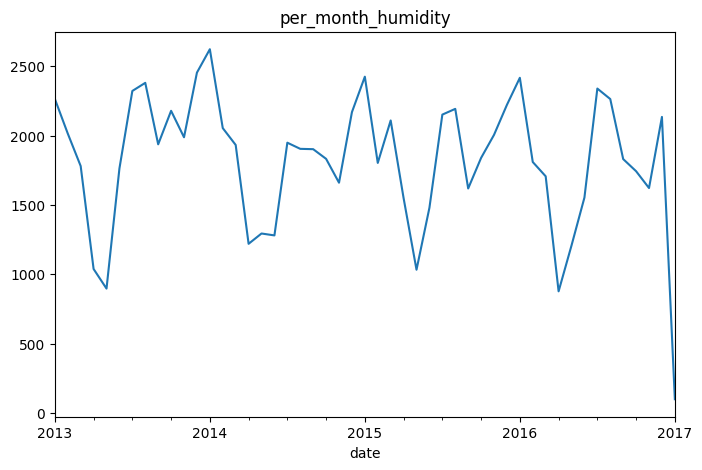

In [41]:
per_month_humidity.plot(figsize = (8,5), title = 'per_month_humidity')

<Axes: title={'center': 'per_month_humidity'}, xlabel='date'>

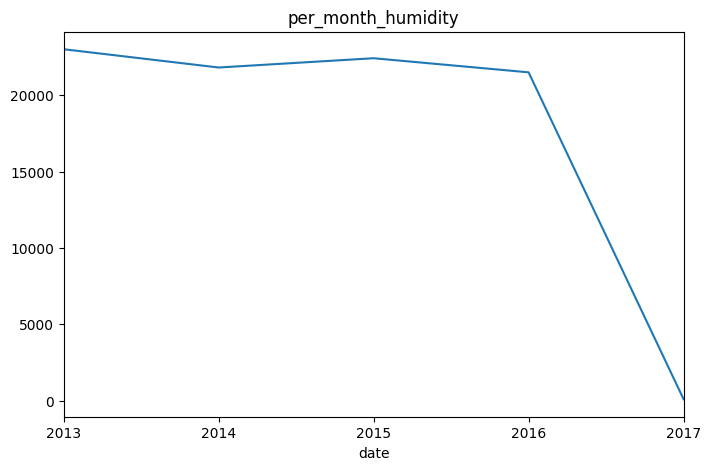

In [43]:
per_year_humidity.plot(figsize = (8,5), title = 'per_month_humidity')

{'whiskers': [<matplotlib.lines.Line2D at 0x7d36447b5d00>,
 'caps': [<matplotlib.lines.Line2D at 0x7d36447b6060>,
 'boxes': [<matplotlib.lines.Line2D at 0x7d36447b7740>],
 'medians': [<matplotlib.lines.Line2D at 0x7d3644db95b0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7d3644db8f20>],
 'means': []}

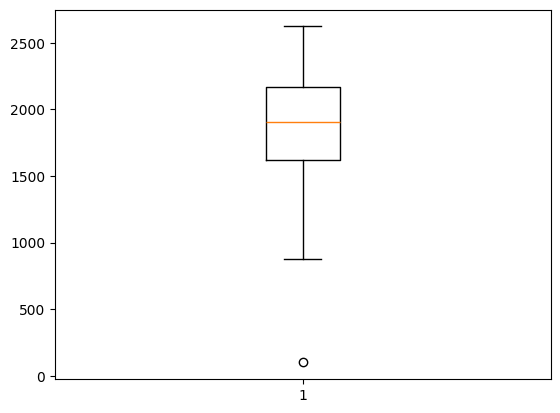

In [44]:
plt.boxplot(per_month_humidity) # checking outlier

to check seasonality and trend

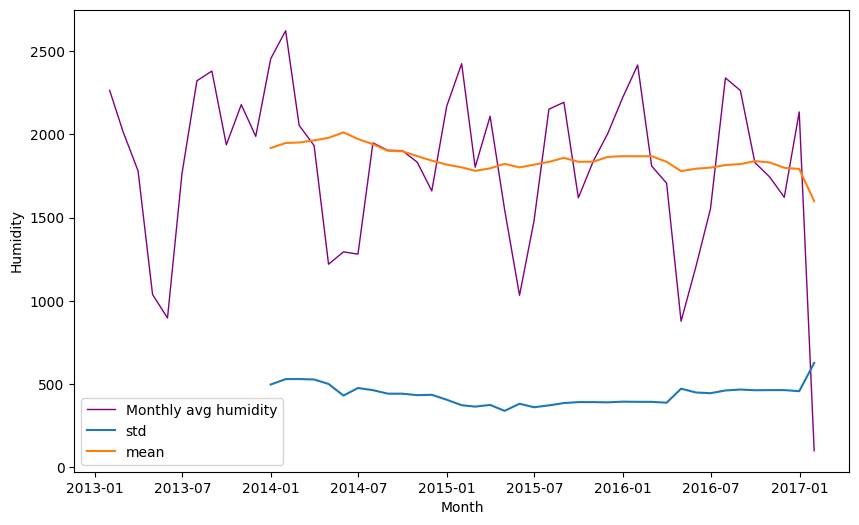

In [53]:
plt.figure(figsize = (10,6))
month_Rolling_std = per_month_humidity.rolling(window = 12).std()
month_Rolling_mean = per_month_humidity.rolling(window = 12).mean()

plt.plot(per_month_humidity, label='Monthly avg humidity',  color='purple', linewidth=1 )
plt.plot(month_Rolling_std, label= 'std')
plt.plot(month_Rolling_mean, label= 'mean')
plt.xlabel('Month')
plt.ylabel('Humidity')
plt.legend()
plt.show()

# **Stationary check Using ADF(Augumented Dickey Fuller) test **

In [57]:
# seasonal decompose to check the presence of the component of Time Series
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

Figure(640x480)


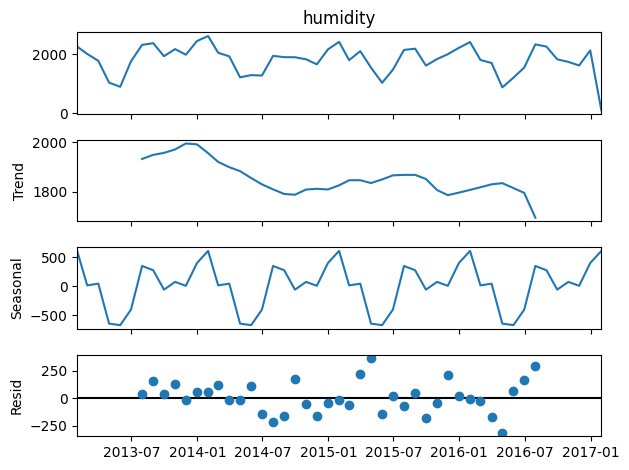

In [56]:
decompose= seasonal_decompose(per_month_humidity)
print(decompose.plot())

In [58]:
result = adfuller(per_month_humidity)
print(f'P-value for Monthly humidity: {result[1]:.2f}') # data is stationay (pvalue <0.05)

P-value for Monthly humidity: 0.01


In [60]:
from statsmodels.graphics.tsaplots import  plot_acf, plot_pacf

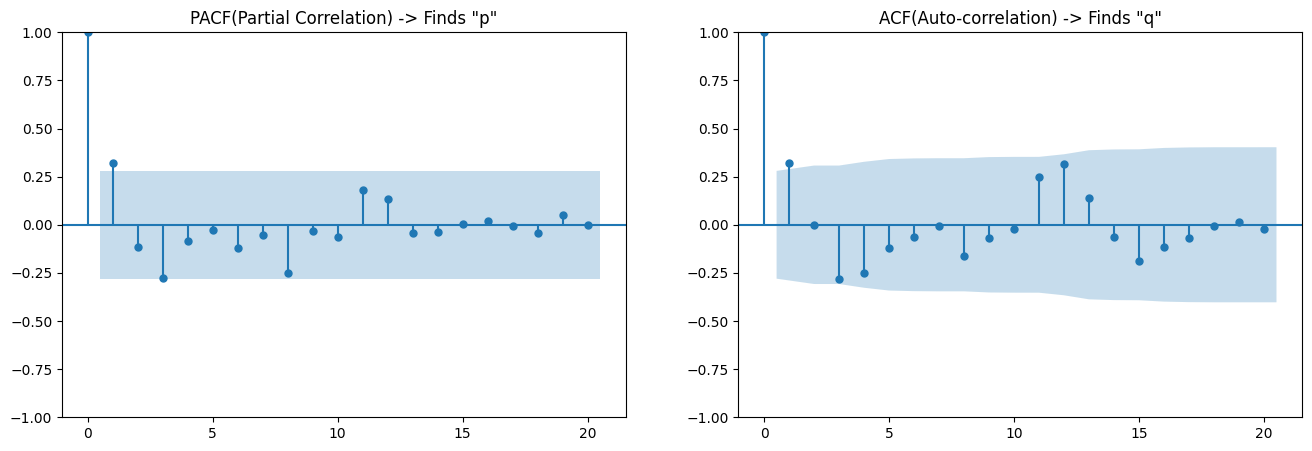

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot PACF to find 'p' (Auto-Regressive)
plot_pacf(per_month_humidity, lags=20, ax=axes[0], method='ywm') # Yule-Walker Method
axes[0].set_title('PACF(Partial Correlation) -> Finds "p"')

# Plot ACF to find 'q' (Moving Average)
plot_acf(per_month_humidity, lags=20, ax=axes[1])
axes[1].set_title('ACF(Auto-correlation) -> Finds "q"')

plt.show()

AUTO ARIMA to find the p,d,q automatically

In [67]:
!pip install pmdarima
import pmdarima as pm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.0 MB/s eta 0:00:00


In [69]:
print("Starting the Auto-ARIMA Search...\n")

# Build and train the automated model
auto_model = pm.auto_arima(
    per_month_humidity,
    seasonal=True,          # we have yearly seasonality
    m=12,                   # 12 months in a season
    start_p=0, max_p=3,     # Search range for p (Auto-Regressive)
    start_q=0, max_q=3,     # Search range for q (Moving Average)
    start_P=0, max_P=2,     # Search range for Seasonal P
    start_Q=0, max_Q=2,     # Search range for Seasonal Q
    d=None,                 # Let the algorithm find the optimal standard difference (d)
    D=1,                    # We know we need exactly 1 seasonal difference
    trace=True,             # Prints the live "battle" between models on screen!
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True           # Uses the fast, smart search algorithm
)

print("\n" + "="*40)
print("🏆 WINNING MODEL SELECTED 🏆")
print("="*40)

Starting the Auto-ARIMA Search...

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=562.529, Time=0.07 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=563.038, Time=3.41 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=563.949, Time=2.17 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=562.365, Time=0.05 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=562.749, Time=0.59 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=562.925, Time=0.22 sec
 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=564.608, Time=0.24 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=562.782, Time=0.08 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=563.493, Time=0.08 sec
 ARIMA(1,0,1)(0,1,0)[12] intercept   : AIC=564.008, Time=0.18 sec

Best model:  ARIMA(0,0,0)(0,1,0)[12]          
Total fit time: 7.138 seconds

🏆 WINNING MODEL SELECTED 🏆


Sarima Model

In [75]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

Training model on the Training set...
Training Complete!



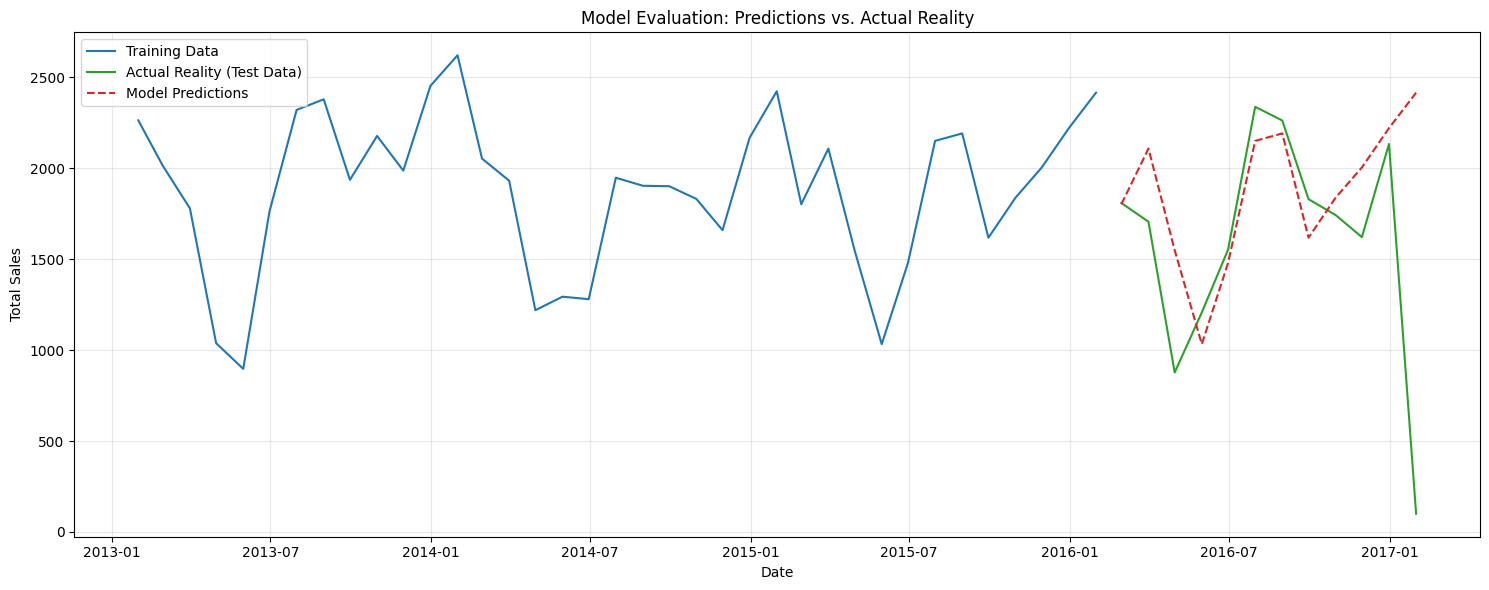

In [76]:
# 1. Split the Data (Hold out the last 12 months for testing)
# We use your original un-differenced data (per_Monthly_sales)
train_data = per_month_humidity.iloc[:-12] # Everything EXCEPT the last 12 months
test_data = per_month_humidity.iloc[-12:]  # ONLY the last 12 months

# 2. Build and Train the Model (ONLY on the training data)
print("Training model on the Training set...")
eval_model = SARIMAX(
    train_data,
    order=(0, 0, 0),               # Replace with your Auto-ARIMA (p, d, q)
    seasonal_order=(0, 1, 0, 12),  # Replace with your Auto-ARIMA (P, D, Q, m)
    enforce_stationarity=False,
    enforce_invertibility=False
)
fitted_eval_model = eval_model.fit(disp=False)
print("Training Complete!\n")

# 3. Generate Predictions for the Test period
# We tell it to predict the exact number of months that are in our test set
predictions = fitted_eval_model.forecast(steps=len(test_data))

# 4. Plot Everything Together
plt.figure(figsize=(15, 6))

# Plot the Training Data (The Past)
plt.plot(train_data.index, train_data, label='Training Data', color='#1f77b4')

# Plot the Actual Test Data (Reality)
plt.plot(test_data.index, test_data, label='Actual Reality (Test Data)', color='#2ca02c')

# Plot the Model's Predictions (The Guess)
plt.plot(predictions.index, predictions, label='Model Predictions', color='#d62728', linestyle='--')

plt.title('Model Evaluation: Predictions vs. Actual Reality')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

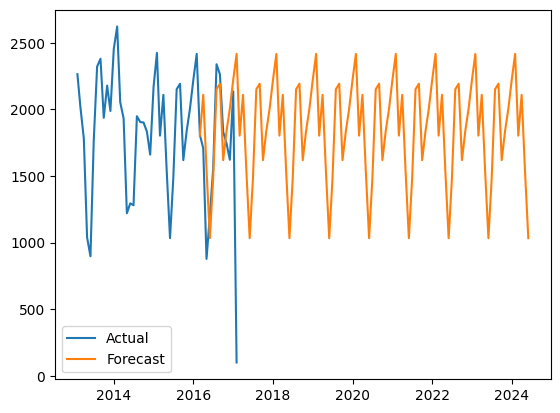

In [83]:
clean_data['forecast'] = fitted_eval_model.predict(
    start=1000, #start and end = indexes
    end=1200,

    dynamic=False
    # dynamic=False:
    # uses ACTUAL past values (real lags)
    # dynamic=True would use predicted values (less accurate)
)


# FUTURE FORECAST
future = fitted_eval_model.get_forecast(steps=100)
# steps=50 → predicting next 50 future time points

forecast_values = future.predicted_mean
# predicted humidity values

confidence_intervals = future.conf_int()
# range (upper/lower bounds) where prediction can lie


plt.plot(per_month_humidity[-200:], label='Actual')
plt.plot(forecast_values, label='Forecast')
plt.legend()
plt.show()